# Paramteric Instabilities
### Caroline Capuano
### Final Project

## <span style="color:pink"> What are parametric instabilities?

Parametric instabilities, or PI's, are a three-mode optomechanical feedback loop when a mirror's acoustic mode/mechanical mode couples with energy from the main laser. The acoustic mode couples with a strong carrier to a higher order optical mode. The instability occurs when the *parametric gain* exceeds 1 (see parametric gain section). Blair descirbes this phenonenom as an "uncontrolled laser powered amplification of acoustic vibrations of the mirrors"$.^{[1]}$

You can consider parametric instabilities as a feedback process:
1. The mirrors acoustic mode scatters the carrier light into a tranverse optical mode
2. The higher order mode (HOM) gets amplified by cavity
3. That beat produces a radiation-pressure force back on the mirror
4. If the feedback is strong enough, the acoustic mode amplitude will grow exponentially


Parametric instabilities are **power-limiting** instabilities. At high enough power, acoustic modes of the mirror can ring up uncontrollably and can cause the interferometer to loose lock. But, to acheive a high enough sensitivity you need a *high* power cavity, so PI's are a barrier to our sensitivity level if left undamped.

### <span style="color:lightblue">Mechanical Modes
Mechanical modes are the natural patterns of vibration that a solid object, like a mirror, can sustain. Every object has a discrete set of these patterns, each with its own characteristic frequency and shape. For example, when you strike a wine glass it rings at a specific pitch — that's its fundamental mechanical mode. A LIGO test mass is no different, except that instead of one or two audible tones it has thousands of distinct vibrational patterns spread across a wide frequency range. Each mode is characterized by two things: the frequency $\omega_m$ of how fast it oscillates, and the mode shape $\vec{u}_m(\vec{r})$. The mode shape describes which parts of the mirror surface move outward, which move inward, and which remain stationary at the nodes.

When investigating parametric instabilities, there are three key factors to consider: the frequency of the mode, the spacial overlap of the mode, and the quality factor $Q_m$. The quality factor describes how long it rings before friction damps it out.

Some types of mechanical modes:
- Drumhead modes — the flat faces of the cylinder flex in and out, like a drumhead being struck. These have the most overlap with the laser beam since the beam hits the flat face directly
- Butterfly modes — the cylinder pinches, like you just hit a drump 

### <span style="color:orange">Step 1: Scattering Carrier Light
The mirror is simultaneously doing two things in this system: it's reflecting the main laser beam (a.k.a "pump field") that circulates in the cavity, and it's also vibrating due to one of its mechanical resonance modes. Because of this vibration, the motion phase-modulates the reflected light when reflected off of the mirror. 

A key aspect in this interaction is the overlap integral between the medanical mode shape and the optical mode shape on the mirror's surface -  the overlap between these two modes is what causes the scattered light $B_{m,n}$. If the mechanical mode has a spatial pattern that overlaps with a particular higher order optical mode, energy transfers efficiently into that mode. If the shapes are orthogonal, no scattering will occur into that mode regardless of how strongly the mirror vibrates. 
*If the mechanical mode has a node where the optical mode has an antinode, they cancel out and very little scattering occurs.*

$$ E_{\text{scatt,n}}=\dfrac{2 \pi i}{\lambda_0} A_m E_{\text{pump}} B_{m,n} $$

The scattering produces two new frequency components: an upper sideband ($\omega_o - \omega_m$) and a lower sideband ($\omega_o + \omega_m$), where $\omega_m$ is the mechanical resonance frequency.

#### Scattered light, so what?
What important about these created sidebands is that they are not lower order modes, $\text{TEM}_{00}$. They are **higher order modes**, HOMs, that are dependent on $B_{m,n}$. Because of this, a single mechanical mode can simultaneously scatter light into many different HOMs, each with its own overlap coefficient $B_{m,n}$.

$$B_{m,n} = \iint_{\text{surface}} f_0 \, f_n (\vec{u}_m \cdot \hat{z}) \, d\vec{r}_\perp$$

Once scattered into a HOM, the light doesn't just escape — it keeps circulating in the cavity.

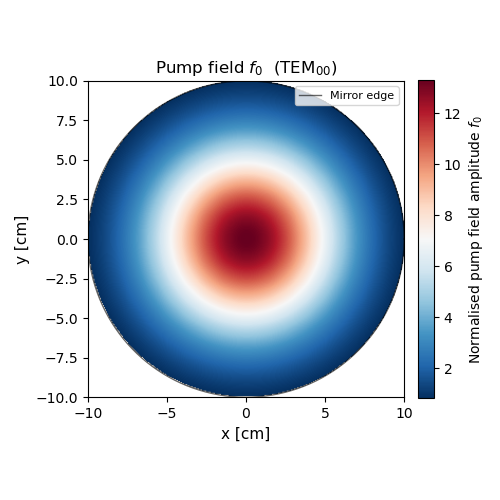

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N          = 300 # resolution
mirror_r   = 0.1 # radius of beam [m]
beam_waist = 0.06 # beam waist [m]

x = np.linspace(-mirror_r, mirror_r, N)
xx, yy = np.meshgrid(x, x) # meshgrid coordinate
r    = np.sqrt(xx**2 + yy**2) # mirror radius
mask = r <= mirror_r # beam must be less than mirror size
dA   = (x[1] - x[0])**2 # area element

def gaussian_beam(xx, yy, beam_waist):
    """
    Create plot for the amplitude of the pump field (input beam - lower order mode TEM00).
    """
    f = np.exp(-(xx**2 + yy**2) / beam_waist**2) # gaussian beam = circular profile
    f /= np.sqrt(np.sum(f**2) * dA)
    return f

f0 = gaussian_beam(xx, yy, beam_waist)
f0_display = f0.copy()
f0_display[~mask] = np.nan

axis_lim = [-mirror_r * 100, mirror_r * 100, # start, end x
            -mirror_r * 100, mirror_r * 100] # start, end y

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('none')

im = ax.imshow(f0_display, axis=axis_lim, origin='lower',
               cmap='RdBu_r')
im.cmap.set_bad(alpha=0)

theta = np.linspace(0, 2 * np.pi, 300) 

ax.plot(mirror_r * 100 * np.cos(theta), # mirror size [cm]
        mirror_r * 100 * np.sin(theta),
        'k-', lw=1.0, alpha=0.6, label='Mirror edge')


plt.colorbar(im, ax=ax, label='Normalised pump field amplitude $f_0$',
             fraction=0.046, pad=0.04)

ax.set_xlabel('x [cm]', fontsize=11)
ax.set_ylabel('y [cm]', fontsize=11)
ax.set_title(r'Pump field $f_0$  (TEM$_{00})$', fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('pump_field.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

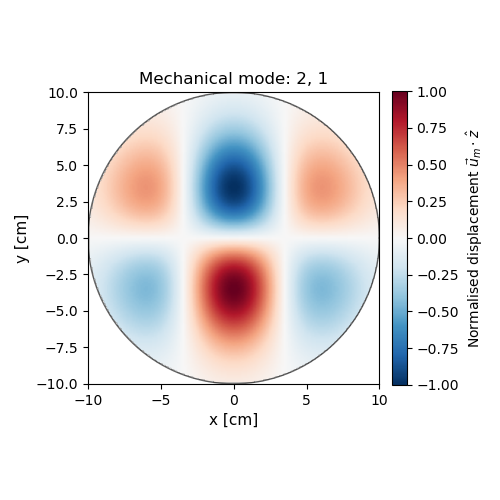

In [64]:
from matplotlib.colors import TwoSlopeNorm
from scipy.special import hermite


p_mech = 2
q_mech = 1


x = np.linspace(-mirror_r, mirror_r, N)
x, y = np.meshgrid(x, x)
R    = np.sqrt(x**2 + y**2)
mask = R <= mirror_r


def mechanical_mode(x, y, p, q, mirror_r):
    """
    Show mechanical mode using Hermite polynomials.
    """
    omega = mirror_r * 0.7     
    Hp    = hermite(p)(np.sqrt(2) * x / omega)
    Hq    = hermite(q)(np.sqrt(2) * y / omega)
    exp   = np.exp(-2*(x**2 + y**2) / omega**2)
    u     = Hp * Hq * exp
    return u / (np.max(np.abs(u)) + 1e-30)   # normalise to [-1, 1]

u_m = mechanical_mode(x, y, p_mech, q_mech, mirror_r)

# mask outside aperture
u_display = u_m.copy()
u_display[~mask] = np.nan

axis = [-mirror_r * 100, mirror_r * 100,
          -mirror_r * 100, mirror_r * 100]   # axes in cm

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(u_display, extent=axis, origin='lower',
               cmap='RdBu_r', norm=norm)

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(mirror_r * 100 * np.cos(theta),
        mirror_r * 100 * np.sin(theta),
        'k-', lw=1.0, alpha=0.6)

x_cm = x * 100

plt.colorbar(im, ax=ax,
             label=r'Normalised displacement $\vec{u}_m \cdot \hat{z}$',
             fraction=0.046, pad=0.04)
ax.set_xlabel('x [cm]', fontsize=11)
ax.set_ylabel('y [cm]', fontsize=11)
ax.set_title(
    rf'Mechanical mode: {p_mech}, {q_mech}',
    fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()



### <span style="color:lightcoral">Step 2: HOM Amplification
The circulation of the sidebands in the cavity will cause them to pick up a phase each round trip ($\phi_{\text{total}} = \phi_{\text{prop}} + \phi_{\text{gouy}}$, where $\phi_{\text{prop}} = \dfrac{4 \pi f L}{c}$ and $\phi_{\text{gouy}} = n \phi_G$). Let's look at the cavity:

The scattering and mirror matrixes are not difficult at all, just model a simple fabry-perot cavity with the HOM sidebands circulating.

<div style="text-align: center;">

![Arm Cavity](pi_cavity.png)

<p style="font-size: 12px;"></p>

</div>

Graph representation:

<div style="text-align: center;">

<img src="pi_directed_graph_cavity.png" alt="Directed graph" width="700"/>

<p style="font-size: 12px;"></p>

</div>

$\renewcommand\identity{1\kern-0.25em\text{l}}$

Let's try and figure out the gain from this cavity amplificiation: $G_n^{\pm} = \vec{e}_x^T(\identity-S_n^{\pm})^{-1}\vec{e}_x$ where $\vec{e}_x$ is the basis vector and $S_n^{\pm}$ is the scattering matrix. First, let's figure out the scattering matrix:

$$
S^{\pm}_n=
\begin{pmatrix}
0 & 0 & 0 & 0 & 0 \\\\
t_A & 0 & 0 & 0 & -r_A \\\\
0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 0 & 0 & 0 \\\\
0 & 0 & -r_B & 0 & 0 \\\\
0 & 0 & 0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 0 \\\\
\end{pmatrix}
$$

Now lets subtract the identity matrix $\identity$ by the scattering matrix:

$$
\identity - S^{\pm}_n=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\\\
t_A & 1 & 0 & 0 & -r_A \\\\
0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 1 & 0 & 0 \\\\
0 & 0 & -r_B & 1 & 0 \\\\
0 & 0 & 0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 1 \\\\
\end{pmatrix}
$$

Now let's invert the matrix to get our transfer functions:

$$
(\identity - S^{\pm}_n)^{-1}=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\\\
\dfrac{t_A}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{r_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
\dfrac{t_Ae^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A e^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
-\dfrac{t_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}& -\dfrac{r_B}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{r_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
-\dfrac{t_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
\end{pmatrix}
$$


So our amplification from the cavity is:

$$
G_n^{\pm} = \vec{e}_x^T(\identity-S_n^{\pm})^{-1}\vec{e}_x = 
\begin{pmatrix}
E_{\text{refl, mirror}} & E_{\text{cav, 0}} & E_{\text{cav, 1}} & E_{\text{cav, 2}} & E_{\text{cav, 3}} & E_{\text{cav, 4}}
\end{pmatrix}
(\identity - S^{\pm}_n)^{-1}
\begin{pmatrix}
E_{\text{refl, mirror}} \\\\
E_{\text{cav, 0}} \\\\
E_{\text{cav, 1}} \\\\
E_{\text{cav, 2}} \\\\
E_{\text{cav, 3}} \\\\
E_{\text{cav, 4}} \\\\

\end{pmatrix}
$$


<!-- $$E_{\text{refl}} = r_1E_{\text{in}} + t_1E_{\text{cav2}} = \boxed{\dfrac{r_1 - r_2e^{2ikL}}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{cav}} = t_1E_{\text{in}} + (-r_1e^{ikL})(-r_2e^{ikL})E_{\text{cav}} = \boxed{\dfrac{t_1}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{cav2}} = -r_2e^{ikL} E_{\text{cav}} = \boxed{\dfrac{-r_2e^{ikL} t_1}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{trans}} = $$ -->

Since we are interested in the gain that is produced from the cavity, the can set the $\vec{e}_x $ to:

$$
\vec{e}_x = 
\begin{pmatrix}
E_{\text{refl, mirror}} \\\\
E_{\text{cav, 0}} \\\\
E_{\text{cav, 1}} \\\\
E_{\text{cav, 2}} \\\\
E_{\text{cav, 3}} \\\\
E_{\text{cav, 4}} \\\\
\end{pmatrix} = 
\begin{pmatrix}
0 \\\\
0 \\\\
0 \\\\
0 \\\\
0 \\\\
1 \\\\
\end{pmatrix} 
$$



Gain Coefficient from cavity is found by the difference between the gain of the upper and gain of the lower sideband: $G_n = G^-_n-G^{+*}_n$

$$
G_n = G^-_n-G^{+*}_n = \dfrac{1}{1-r_A r_Be^{2i(\phi_n - \dfrac{\omega_m L}{c})}} - \dfrac{1}{1-r_A r_Be^{-2i(\phi_n + \dfrac{\omega_m L}{c})}} 
$$

<!-- $$G_n^\pm = \boxed{\dfrac{t_A}{1-r_Ar_Be^{i\phi_{total}^\pm}}} = \boxed{\dfrac{t_A}{1-r_Ar_Be^{i(\dfrac{2(\omega_0 \pm \omega_m)L}{c} - n \phi_{G, rt})}}}$$ -->

Let's try adding some parameters so that we can solve the real part of this transfer function (this is what is needed to calculated $B_{m,n}$)


| Parameter (LIGO) |  Value |
|---------------|-----------------|
| Cavity Length [m] | 3994.5 |
| Input Mirror transmittance | 0.014 |
| End Mirror transmittance | $10^{-5}$ |
| Frequency of mode $\omega_m$ [Hz] | 29950 |
| Phase $\phi_n$ [rad] |             |





In [ ]:
c       = 3e8   # speed of light [m/s]
L       = 3994.5  # cavity length [m]

T_I     = 0.014 # input mirror power transmissivity
T_E     = 1e-5   # end mirror power transmissivity
r_A     = np.sqrt(1 - T_I)
r_B     = np.sqrt(1 - T_E)

phi_G   = np.deg2rad(156)  # round-trip Gouy phase [rad]
n       = 2    # HOM order  (p + q)
phi_n   = -n * phi_G   # round-trip HOM phase [rad]

f = 29950 # eigenfreqency of higher order mode [Hz]
omega_m = 2 * np.pi * f  # mechanical mode frequency [rad/s]

G_minus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n - omega_m * L / c)))
G_plus  = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n + omega_m * L / c)))

Gn = G_minus - np.conj(G_plus)

print(f"G_minus = {G_minus:.4f}")
print(f"G_plus  = {G_plus:.4f}")
print(f"Gn      = {Gn:.4f}")
print(f"Re[Gn]  = {Gn.real:.4f}")

G_minus      = 0.5018+0.0487j
G_plus       = 0.5439+2.4432j
Gn           = -0.0421+2.4919j
Re[Gn]       = -0.0421


### <span style="color:#CD5C5C"> Step 3: Radiation Pressure
After the scattered HOM has circulated around the cavity and been amplified, it comes back to the same mirror surface and interferes with the pump field. This is where the magic happens. The optical field can couple back into the mechanical mode. Instead of scattering, this interaction will cause a radiation pressure on the mirror.If the phase is right, this force drives the mechanical mode further — amplifying the original vibration rather than damping it. The mirror then scatters more light, which gets amplified, which pushes the mirror harder. 

$$F_{\text{rad}} = \dfrac{2}{c} E_{\text{pump}}^* \sum_{n=0}^\infty B_{m,n} E_{\text{return, n}}$$


### <span style="color:#FF474C"> Step 4: Instability

The parametric gain is how we understand how strongly the mode interaction drives the acoustic mode. Think of it like a threshold: consider the ratio of the radiation-pressure ennergy fed into the mode to the mechaincal energy the mode looses by damping. If the parametric gain is less than one, the the mode damping is dominating; if the parametric gain is equal to one, it is at the instability threshold; if the gain is greater than one, then the mode rings up and becomes unstable:
 - <span style="color:green">R_m &lt; 1 : the mode is damped</span> 
 - $R_m$ = 1 : intability threshold
 - <span style="color:red">R_m &gt; 1 : the mode rings up</span> 


Parametric gain equation:

$R_m = \dfrac{4 \pi Q_m P_{\text{circ}}}{M \omega^2_m c \lambda_0} \sum_{n=0}^\infty \mathbb{R}[G_n]B^2_{m,n}$

The parametric gain is directly portional to the mechaincal mode $Q_m$, power $P_{\text{circ}}$ and the spatial overlap between the optical and mechanical mode $B_{m,n}$. 

## <span style="color:#967BB6"> Modeling Mode Interaction

In [ ]:
import numpy as np

# parameters
L       = 3994.5 # arm length [m]
c       = 3e8  # speed of light [m/s]
FSR     = c / (2 * L) # ~37.5 kHz

# cavity
T_ITM   =  1 # input mirror power transmission
T_ETM   =  1 # end mirror power transmission
r_ITM   = np.sqrt(1 - T_ITM)
r_ETM   = np.sqrt(1 - T_ETM)

F       = np.pi * np.sqrt(r_ITM * r_ETM) / (1 - r_ITM * r_ETM) # cavity finesse 
delta   = FSR / (2 * F)   # half-linewidth [Hz]

gouy_rt = 1 # Gouy phase per round trip [radians] 

def cavity_amplitude(delta_f, mode_order, gouy_rt_rad, r1=r_ITM, r2=r_ETM, t1=np.sqrt(T_ITM)):
    """
    Cavity field amplitude for HOM of order n.
        delta_f  : frequency offset from carrier [Hz]
        mode_order: n 
    """

    phi_prop  = 4 * np.pi * delta_f * L / c   # round-trip propagation
    phi_gouy  = mode_order * gouy_rt_rad   # HOM Gouy shift (round-trip)
    phi_total = phi_prop - phi_gouy    # total round-trip phase

    denom = 1 - r1 * r2 * np.exp(1j * phi_total)
    return np.abs(t1 / denom)



### How are PI's damped in LIGO?
There are two main strategies for damping parametric instabilities: change the spatial overlap,  reduce the mechanical mode Q factor

#### 1. Thermal Tuning using Ring Heaters

This attacks the optical side of the feedback loop by shifting the HOM resonance frequencies away from mechanical mode frequencies. The mirror radius of curvature is not a fixed parameter but a dynamic and tunable variable. Since this curvature directly tunes the instability gain, it is possible to find a solution to instabilities over the range of mirror radii of curvature within which the detector will operate. LIGO uses a **ring heater** - a glass torus wrapped in nichrome wire through which current is dissipated to heat the barrel of the optic it encircles. It can be used to tune the g-factor and higher order mode spacing of the Fabry-Perot arms to assist in the control of parametric instabilities.

#### 2. Passive Damping using Acoustic Mode Dampers (AMDs)
Each test mass is equipped with four different AMDs distributed on the optic's flats. Each AMD is made of a base, a shunted shear plate and a reaction mass, where the shunted shear plate is used as a lossy tunable spring with a complex stiffness.

#### 3. Active Damping using Electrostatic Drive (ESD)
The electrostatic drive (ESD) damps parametric instabilities by s\applying a feedback force directly to the test mass surface at the same frequency but with opposite phase. This reduces the effective $Q_m$ of the unstable mode, which directly brings $\mathcal{R}_m​$ below 1.

<div style="text-align: center;">

![Damping PIs in LIGO](damping_pi_ligo.png)

<p style="font-size: 12px;">Figure 1: Damping PIs in LIGO. From Blair et al. (2017)<sup>[3]</sup></p>

</div>

## <span style="color:lightblue"> Resources

[1] Blair, Carl. *Parametric Instability in Gravitational Wave Detectors.* Diss. University of Western Australia, 2017.

[2] Evans, M., L. Barsotti, and P. Fritschel. "A General Approach to Optomechanical Parametric Instabilities." *arXiv,* 14 Oct. 2009, arXiv:0910.2716v1

[3] Blair, Carl, et al. "First Demonstration of Electrostatic Damping of Parametric Instability at Advanced LIGO." *Physical Review Letters*, vol. 118, no. 15, Apr. 2017, doi:10.1103/PhysRevLett.118.151102.

[4] 
